## Games and Students Dataset Exploration

### **Business Problem**: what are the top features that influence students earning higher grades in regard to home life and video game habbits.

### **Table of Contents**
* [Data Collection](#collect)
* [Data Cleaning](#clean)
* [Exploratory Data Analysis](#eda)
* [Data Dictionary](#dic)
* [Applying ML Models](#model)
* [Additional Experimentation with Other ML Models](#other)
* [Summary](#sum)


####  About Dataset

The dataset provides valuable insights into the demographics and gaming habits of students, capturing various attributes that could be analyzed to uncover meaningful correlations. Each entry in the dataset includes the student's gender, identified as either "Female" or "Male," along with a unique school code that serves as an identifier for each institution. This allows for the categorization and grouping of students based on their respective schools, enabling comparative analyses across different educational institutions.

One of the key aspects covered in the dataset is the student's gaming experience, which includes the number of years they have been playing games. This attribute can indicate whether gaming is a long-term habit or a relatively new activity for the student. Additionally, the dataset records how frequently students engage in gaming, likely measured on a scale from 1 to 5, providing a quantitative representation of their gaming intensity. To further elaborate on gaming engagement, the dataset also tracks the average number of hours a student spends playing games daily. This metric can be crucial in understanding whether extended gaming sessions have an impact on academic performance. Moreover, the dataset distinguishes whether a student actively plays games or not, which can be particularly useful in comparative studies assessing the behaviors of gaming versus non-gaming students.

Beyond gaming habits, the dataset delves into socioeconomic factors by including the annual income of the student's family. This "Parent Revenue" variable can help researchers examine the potential influence of economic background on a student's gaming behavior and academic performance. Additionally, the education levels of both the student's father and mother are recorded, offering insights into whether parental education has any correlation with the student's gaming frequency, academic performance, or gaming choices.

Academic performance is another critical component of this dataset, represented by the "Grade" variable, which provides a measure of the student's academic standing. This information can be instrumental in investigating how gaming habits, parental background, and socioeconomic status contribute to or hinder academic success.

This dataset presents an excellent opportunity for analysis on platforms like Kaggle. Potential research directions could include exploring the relationship between gaming frequency and academic performance, investigating whether students from higher-income families spend more or fewer hours gaming, or analyzing if parental education has any impact on the types of games students play or their duration of play. By leveraging this dataset, researchers can identify trends and generate insights that may inform policies on gaming habits, parental involvement, and educational strategies.

[Games and Students Kaggle page](https://www.kaggle.com/datasets/willianoliveiragibin/games-and-students)

<a id='collect'></a>
# Collect Data
---
* This data is a dataset named "Games and Students" collected as a .csv file from Kaggle

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_csv('gameandgrade new.csv')

In [84]:
df.head()

,sex,school_code,playing_years,playing_often,playing_hours,playing_games,parent_revenue,father_education,mother_education,grade
0,0,1,1,2,1,1,4,4,5,77.5
1,1,1,1,3,1,1,1,3,3,83.0
2,0,1,0,0,0,0,1,3,3,80.0
3,0,1,3,5,1,1,2,2,3,45.0
4,1,1,1,1,2,1,1,3,4,85.0


In [4]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Sex               770 non-null    int64 
 1   School Code       770 non-null    int64 
 2   Playing Years     770 non-null    int64 
 3   Playing Often     770 non-null    int64 
 4   Playing Hours     770 non-null    int64 
 5   Playing Games     770 non-null    int64 
 6   Parent Revenue    770 non-null    int64 
 7   Father Education  770 non-null    int64 
 8   Mother Education  770 non-null    int64 
 9   Grade             770 non-null    object
 10  percentage        770 non-null    object
dtypes: int64(9), object(2)
memory usage: 66.3+ KB


* There appears to be 770 records with no null or missing values in the dataset.
* There are 9 int columns and two objects. The Grade column data type will need to be a float.
* Remove percentage, its redundant information. 

In [5]:
# Statistics of the dataset
df.describe()

,Sex,School Code,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000
mean,0.498701,4.944156,1.584416,2.242857,1.488312,0.706494,1.837662,3.718182,3.410390
std,0.500323,2.999913,1.407306,1.923635,1.337853,0.458509,1.064077,1.171756,1.176447
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.250000
50%,0.000000,4.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000,3.000000
75%,1.000000,8.000000,3.000000,4.000000,2.000000,1.000000,2.000000,5.000000,4.000000
max,1.000000,11.000000,4.000000,5.000000,5.000000,2.000000,4.000000,6.000000,6.000000


In [6]:
# Count missing values in each column
df.isnull().sum()

Sex                 0
School Code         0
Playing Years       0
Playing Often       0
Playing Hours       0
Playing Games       0
Parent Revenue      0
Father Education    0
Mother Education    0
Grade               0
percentage          0
dtype: int64

* There are no missing values in the data set.

In [7]:
# dislay duplicate values
df.duplicated().sum()

np.int64(16)

In [8]:
# Display duplicated values that are true
df[df.duplicated()]

,Sex,School Code,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education,Grade,percentage
278,0,4,0,0,0,0,2,3,4,70.00,"7000,00%"
367,0,4,0,0,0,0,1,3,2,70.00,"7000,00%"
419,0,5,0,0,0,0,2,5,4,100,"10000,00%"
468,0,7,0,0,0,0,0,4,4,100,"10000,00%"
478,0,7,0,0,0,0,0,5,5,100,"10000,00%"
480,0,7,0,0,0,0,0,6,6,100,"10000,00%"
610,0,9,0,0,0,0,0,5,5,100,"10000,00%"
616,0,9,0,0,0,0,0,6,6,100,"10000,00%"
617,0,9,0,0,0,0,0,5,6,100,"10000,00%"
618,0,9,0,0,0,0,0,6,6,100,"10000,00%"


* Since there is a high chance that the duplicate values are different students, I will leave them in the data set.

<a id='clean'></a>
# Data Cleaning
---

In [9]:
# rename columns for better readability
df.rename(columns={
    'School Code': 'school_code',
    'Sex': 'sex',
    'Playing Years': 'playing_years',
    'Playing Often': 'playing_often',
    'Playing Hours': 'playing_hours',
    'Playing Games': 'playing_games',
    'Parent Revenue': 'parent_revenue',
    'Father Education': 'father_education',
    'Mother Education': 'mother_education',
    'Grade': 'grade',
}, inplace=True)

In [10]:
# Drop 'percentage' column
df.drop(columns=['percentage'], inplace=True)

In [11]:
# find unique values in the 'grade' column
df['grade'].unique()

array(['77.50', '83.00', '80.00', '45.00', '85.00', '55.00', '60.00',
       '88.00', '90.00', '74.00', '95.00', '50.00', '98.00', '87.00',
       '70.00', '65.00', '76.50', '61.00', '99.00', '77.00', '100',
       '75.00', '69.00', '67.00', '79.00', '36.50', '92.00', '93.00',
       '90.70', '78.00', '68.00', '64.00', '42.35', '72.50', '40.00',
       '63.00', '86.00', '62.00', '89.00', '48.00', '57.75', '94.00',
       '66.00', '71.00', '91.00', '57.00', '76.00', '73.00', '97.66',
       '82.50', '98.50', '78.50', '94.50', '95.24', '65.50', '85.50',
       '93.50', '90.80', '86.70', '59.00', '92.60', '53.00', '72.00',
       '82.00', '42.50', '92.50', '80.50', '83.50', '50.60', '97.50',
       '89.50', '55.50', '96.50', '52.00', '56.00', '67.20', '97.00',
       '92..00', '43.00', '59.69', '87.50', '90.50', '90', '67.50',
       '33.00', '85.30', '70.50', '49.53', '72.10', '80.33', '56.50',
       '96.00', '75.60', '79.80', '84.00', '95.33', '46.50', '95.50',
       '75.50', '60.50',

In [12]:
# change value where 'grade' is 92..00 to 92.0
df['grade'] = df['grade'].replace('92..00', '92.0')

In [13]:
# Fix data type mismatch
df['grade'] = df['grade'].astype('float')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               770 non-null    int64  
 1   school_code       770 non-null    int64  
 2   playing_years     770 non-null    int64  
 3   playing_often     770 non-null    int64  
 4   playing_hours     770 non-null    int64  
 5   playing_games     770 non-null    int64  
 6   parent_revenue    770 non-null    int64  
 7   father_education  770 non-null    int64  
 8   mother_education  770 non-null    int64  
 9   grade             770 non-null    float64
dtypes: float64(1), int64(9)
memory usage: 60.3 KB


<a id='eda'></a>
# Exploratory Data Analysis
---

<a id='dic'></a>
### **Data dictionary**
* Sex- 0 female/ 1 male. (Unsure if it should be 0 male/ 1 female, going by listing in data card)
* School Code- unique school identifier.
* Playing Years- number of years the student has played games.
* Playing Often- how often they play games on a scale of 0-5.
* Playing Hours- number of hours playing games on a scale of 0-5.
* Playing Games- Is the student actively playing games now?
* Parent Revenue- parernt's economic status on a scale of 0-5 .
* Father Education- Father's education level on a scale of 0-6.
* Mother Education- Mother's education level on a scale of 0-6.
* Grade- student's grade as a percentage.
* Percentage- column not needed. Supposed to be student's grade percentage.

In [58]:
df.describe()

,sex,school_code,playing_years,playing_often,playing_hours,playing_games,parent_revenue,father_education,mother_education,grade
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000
mean,0.498701,4.944156,1.584416,2.242857,1.488312,0.705195,1.837662,3.718182,3.410390,77.518870
std,0.500323,2.999913,1.407306,1.923635,1.337853,0.456252,1.064077,1.171756,1.176447,16.511119
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.250000,65.000000
50%,0.000000,4.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000,3.000000,80.000000
75%,1.000000,8.000000,3.000000,4.000000,2.000000,1.000000,2.000000,5.000000,4.000000,90.000000
max,1.000000,11.000000,4.000000,5.000000,5.000000,1.000000,4.000000,6.000000,6.000000,100.000000


* It is unknown what the scale for playing games, parent revenue and mother/father education is.
* The data card lists Playin often and playing hours as a scale of 0-5.
* The mean average grade is 77.52 with the minimun grade being 33.00 and the max being 100.00.
* The dataset is divided close to equally between male and female.
* The average playing_years is 1.6.
* The average for playing_often is 2.2
* The average for playing_hours is 1.5
* The average for playing_games is 0.7
* The average for parent_revenue is 1.8
* The average for father_education is 3.7
* The average for mother_education is 3.4

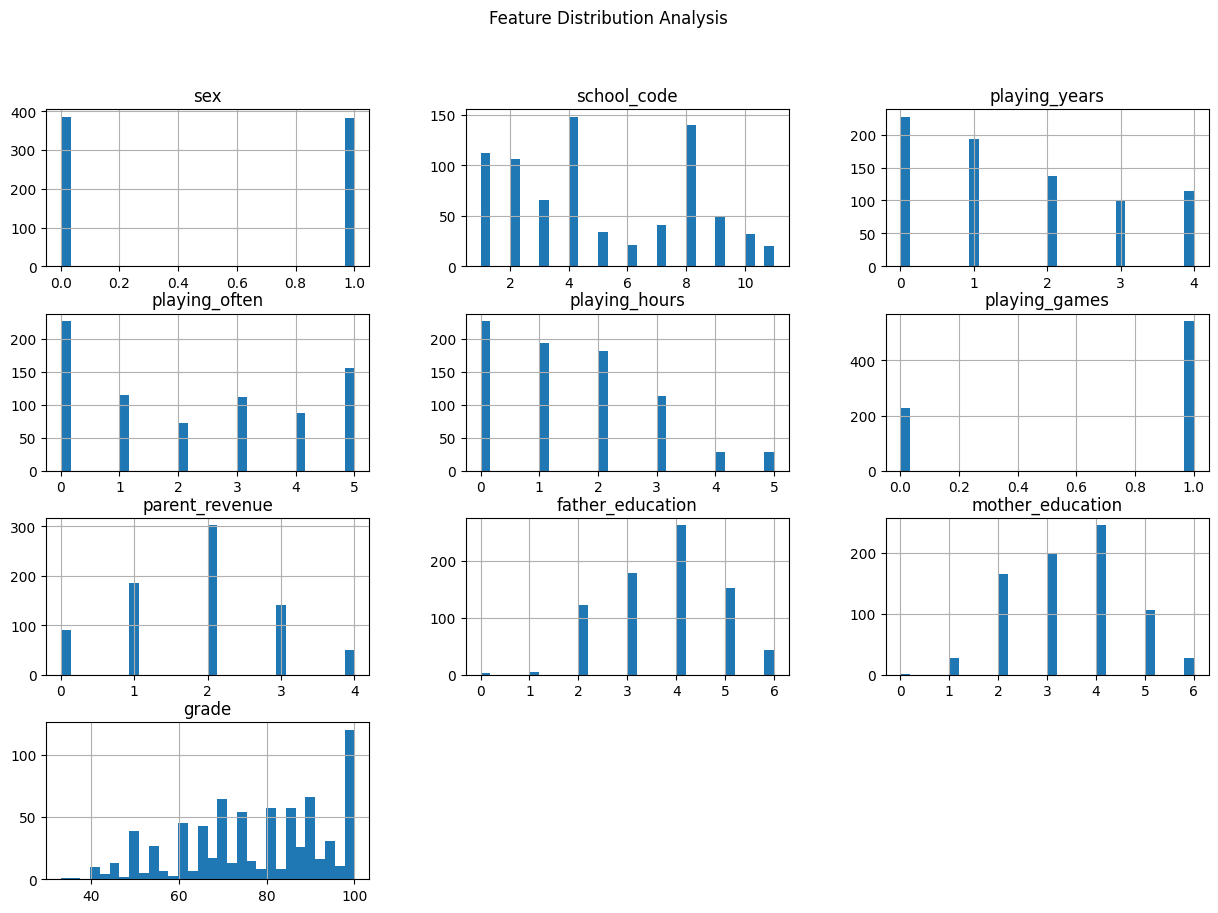

In [55]:
df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Feature Distribution Analysis')
plt.show()


In [49]:
def create_grade_pivot_table(df, index_column):
    """
    Function to create a pivot table comparing grades with a specified index column.

    Parameters:
    df (DataFrame): The input DataFrame.
    index_column (str): The column to use as the index for the pivot table.

    Returns:
    DataFrame: The resulting pivot table.
    """
    # Create a pivot table
    pivot_table = df.pivot_table(
        values='grade', 
        index=index_column, 
        aggfunc=['mean', 'min', 'max', 'count']
    )
    
    # Return the pivot table
    return pivot_table

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_grades_vs_column(df, col, grade_column='grade'):
    """
    Function to create a boxplot showing the relationship between a specified column and grades.

    Parameters:
    df (DataFrame): The input DataFrame.
    col (str): The name of the column to compare with grades.
    grade_column (str): The name of the column representing grades (default is 'grade').

    Returns:
    None
    """
    # Filter Relevant Columns
    filtered_data = df[[col, grade_column]]

    # Create a Visualization
    plt.figure(figsize=(10, 6))  # Set the figure size
    sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot

    # Add a title and labels to the plot
    plt.title(f'{col.capitalize()} vs Grade', fontsize=16)
    plt.xlabel(col.capitalize(), fontsize=12)
    plt.ylabel(grade_column.capitalize(), fontsize=12)

    # Display the plot
    plt.show()

---
## Comparing Sex VS Grades

In [54]:
pivot_table = create_grade_pivot_table(df, 'sex')
print(pivot_table)

          mean   min    max count
         grade grade  grade grade
sex                              
0    79.739067  36.5  100.0   386
1    75.287109  33.0  100.0   384


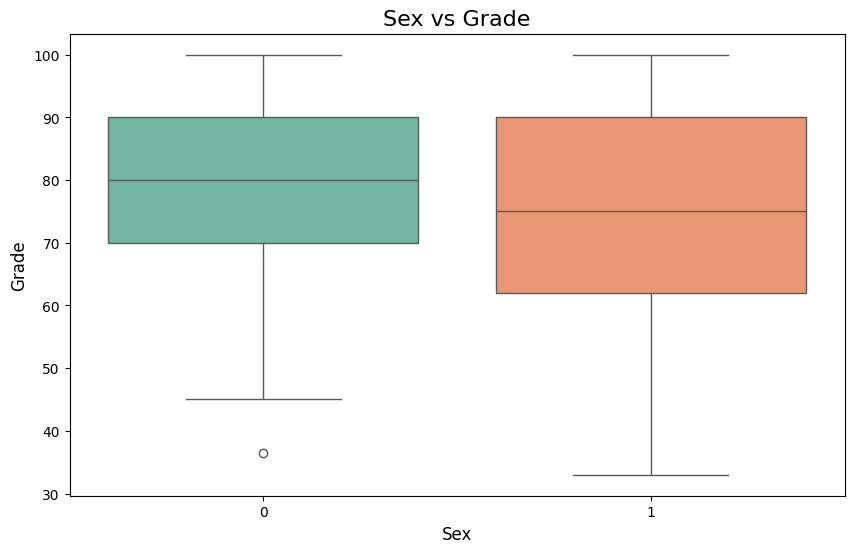

In [86]:
plot_grades_vs_column(df, 'sex')

* Female students have higher average grades 4.4% with a higher minimum score by 3.5%.
* Both male and female students have the same high score of 100%.
* There appears to be an outlier in the 0 (female column).

----------------------------------------------
## Comparing School Code VS Grades

In [51]:
pivot_table = create_grade_pivot_table(df, 'school_code')
# Display the pivot table
print(pivot_table)

                  mean   min    max count
                 grade grade  grade grade
school_code                              
1            72.658929  36.5  100.0   112
2            72.708962  40.0   98.5   106
3            69.675758  45.0  100.0    66
4            73.181014  40.0   99.0   148
5            93.367647  72.5  100.0    34
6            96.190476  70.0  100.0    21
7            96.829268  85.0  100.0    41
8            75.216857  33.0  100.0   140
9            95.270000  60.0  100.0    50
10           76.791562  45.0  100.0    32
11           74.975000  50.0   95.5    20


C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


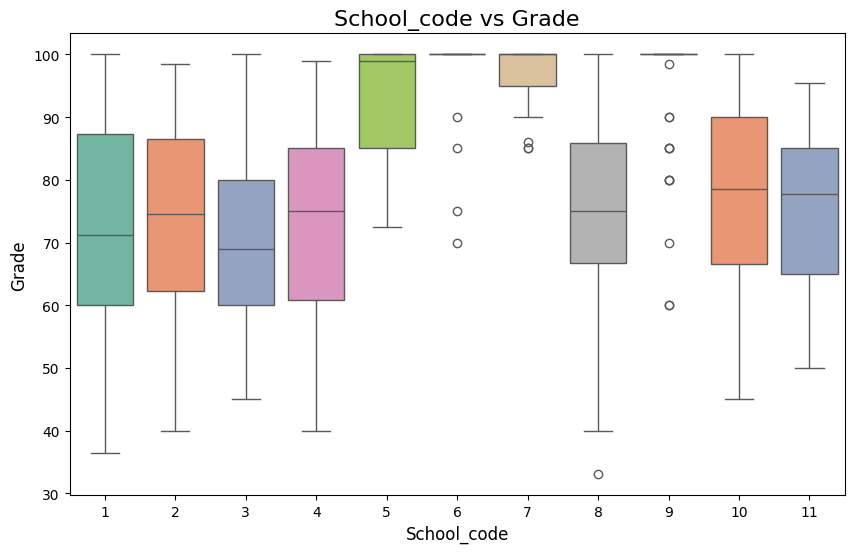

In [65]:
plot_grades_vs_column(df, 'school_code')

* In general, schools with smaller amounts of students have higher average grades and higher minimum grades and higher maximum grades.

---
## Comparing Playing Years VS Grades

In [53]:
pivot_table = create_grade_pivot_table(df, 'playing_years')
# Display the pivot table
print(pivot_table)

                    mean   min    max count
                   grade grade  grade grade
playing_years                              
0              81.510881  36.5  100.0   227
1              75.300622  40.0  100.0   193
2              76.025109  33.0  100.0   137
3              77.412121  40.0  100.0    99
4              75.213158  40.0  100.0   114


C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


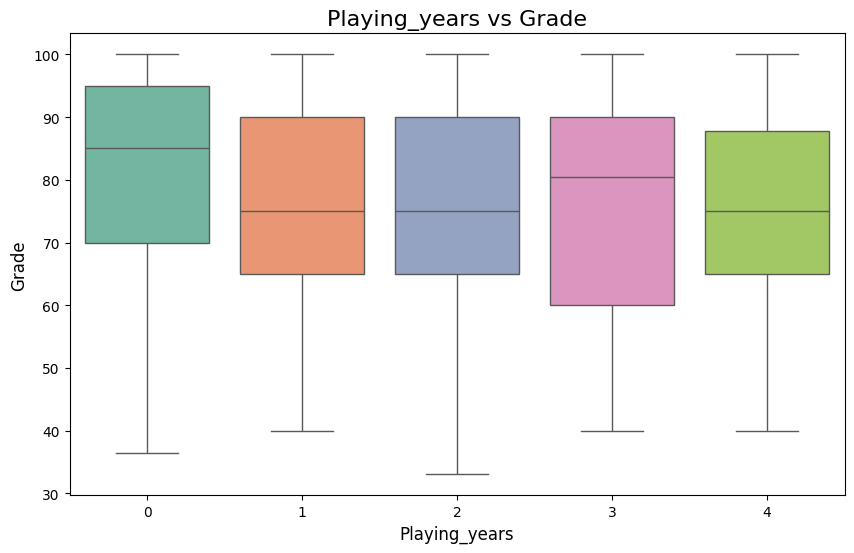

In [66]:
plot_grades_vs_column(df, 'playing_years')

* Most students have only been playing for 0 to 1 years.
* It appears that students who haven't played games for a year have better score than those who have been playing for at least a year.

* Those who play the least often in the 0 category have the highest grades.

---
## Comparing Playing Hours VS Grades

In [60]:
pivot_table = create_grade_pivot_table(df, 'playing_hours')
# Display the pivot table
print(pivot_table)

                    mean   min    max count
                   grade grade  grade grade
playing_hours                              
0              81.510881  36.5  100.0   227
1              77.440829  33.0  100.0   193
2              75.227514  40.0  100.0   181
3              75.754867  40.0  100.0   113
4              72.803571  40.0  100.0    28
5              72.339286  40.0  100.0    28


C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


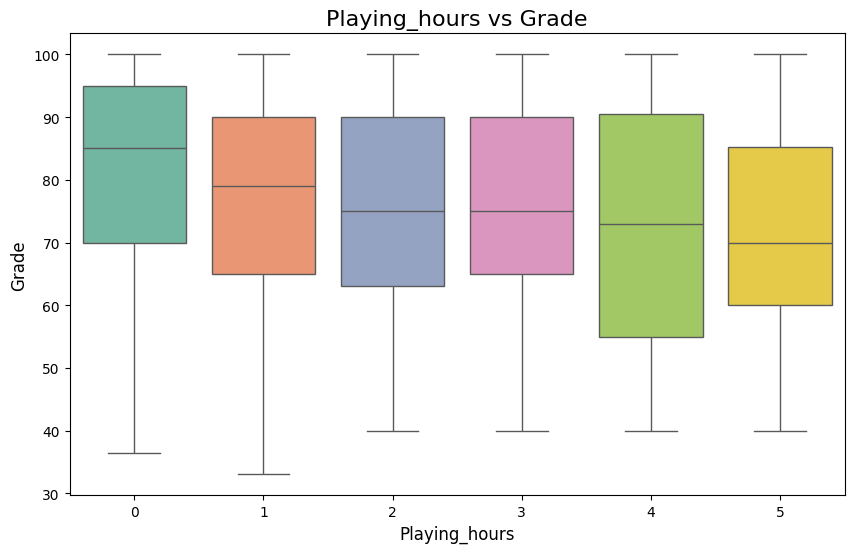

In [67]:
plot_grades_vs_column(df, 'playing_hours')

* There appears to be an inverse relationship between hours spent playing games and grades.
* The less time spent playing games the higher the grades.

* Category 2 is an outlier. I am going to change it to 1 under because I feel it is a typo.


---
## Comparing Playing Games Vs Grades

In [24]:
# change value where 'playing_games' is 2 to 1
df['playing_games'] = df['playing_games'].replace(2, 1)

In [68]:
pivot_table = create_grade_pivot_table(df, 'playing_games')
# Display the pivot table
print(pivot_table)

                    mean   min    max count
                   grade grade  grade grade
playing_games                              
0              81.510881  36.5  100.0   227
1              75.850018  33.0  100.0   543


C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


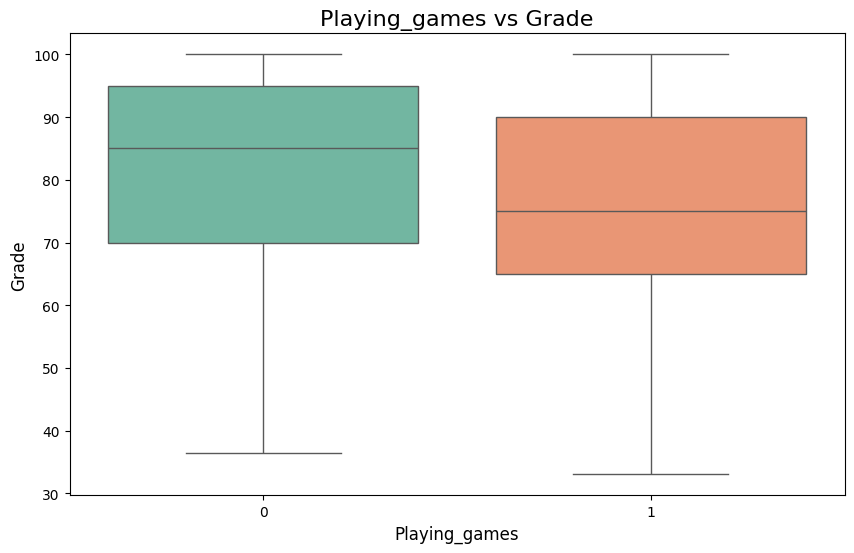

In [69]:
plot_grades_vs_column(df, 'playing_games')

* Students who are currently playing games have lower grades than those who are not currently playing games by 5.9%

---
## Comparing Parent Revenue VS Grades

In [70]:
pivot_table = create_grade_pivot_table(df, 'parent_revenue')
# Display the pivot table
print(pivot_table)

                     mean    min    max count
                    grade  grade  grade grade
parent_revenue                               
0               95.972527  60.00  100.0    91
1               68.808541  33.00  100.0   185
2               75.295232  40.00  100.0   302
3               78.895070  40.00  100.0   142
4               85.683800  49.53  100.0    50


C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


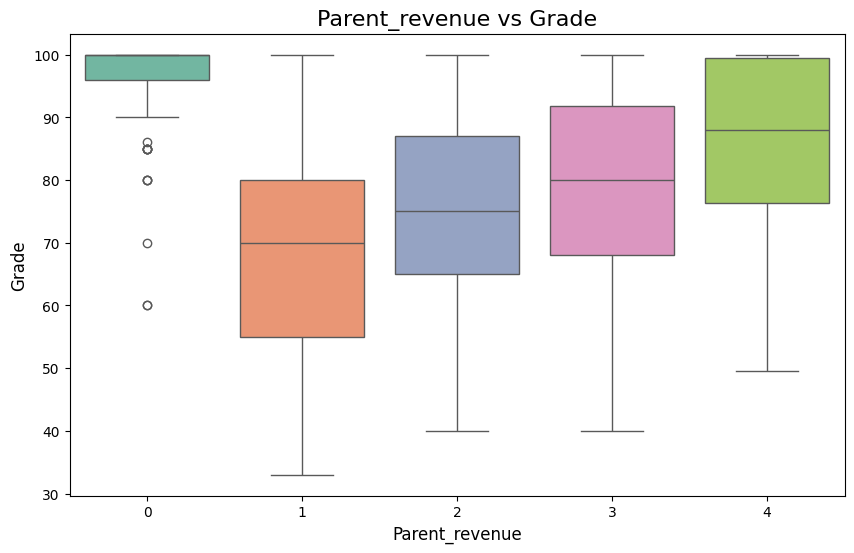

In [71]:
plot_grades_vs_column(df, 'parent_revenue')

* Students who's parents make the least money have the highest grades in this dataset with a drop off of 28% to those in category 1.
* As wages increase student's grades increase in each category.
* There is a possiblity that students who's parents have the lowest wages cannot afford games. Thus those students don't spend as much time playing games.


---
## Comparing Father Education VS Grades

In [72]:
pivot_table = create_grade_pivot_table(df, 'father_education')
# Display the pivot table
print(pivot_table)

                       mean   min    max count
                      grade grade  grade grade
father_education                              
0                 95.000000  90.0  100.0     4
1                 76.083333  65.0   95.5     6
2                 70.817236  33.0  100.0   123
3                 71.463371  36.5  100.0   178
4                 78.087328  40.0  100.0   262
5                 84.654575  40.0  100.0   153
6                 91.159091  64.0  100.0    44


C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


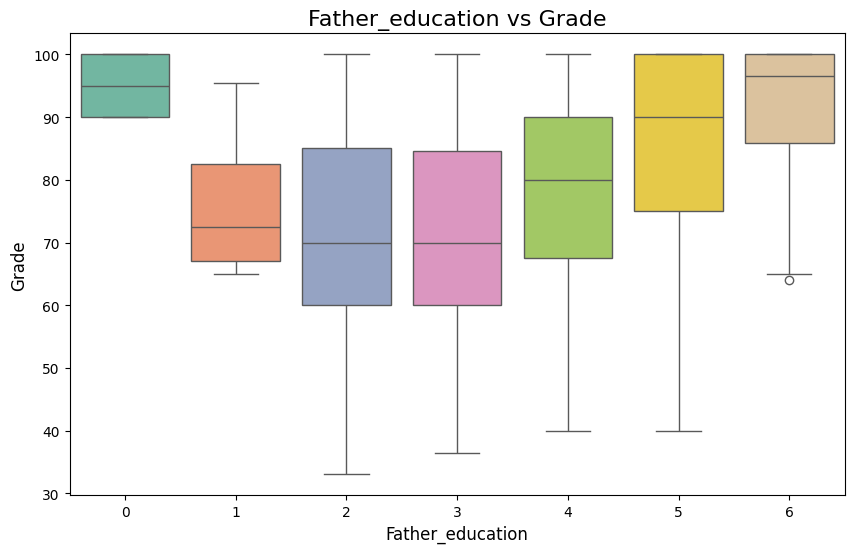

In [74]:
plot_grades_vs_column(df, 'father_education')

* The 4 students who's fathers have the lowest education level have the highest average grades.
* The majority of the student's father's education level falls between 2 and 5.
* As the father's education level increases from level 2 the student grades increase.

---
## Comparing Mother Education Vs Grades

In [75]:
pivot_table = create_grade_pivot_table(df, 'mother_education')
# Display the pivot table
print(pivot_table)

                        mean    min    max count
                       grade  grade  grade grade
mother_education                                
0                 100.000000  100.0  100.0     1
1                  63.097407   36.5   98.0    27
2                  72.899939   33.0  100.0   165
3                  73.547387   40.0  100.0   199
4                  79.612327   40.0  100.0   245
5                  86.348679   50.0  100.0   106
6                  94.944444   65.0  100.0    27


* There is one outlier for mother_education who's child had a perfect score. 
* From mother_education level 1 on, the student grades increase from 63.1% at level 1 to 94.9% at level 6. 

C:\Users\jerem\AppData\Local\Temp\ipykernel_5564\2771542583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=grade_column, data=filtered_data, palette='Set2')  # Create the boxplot


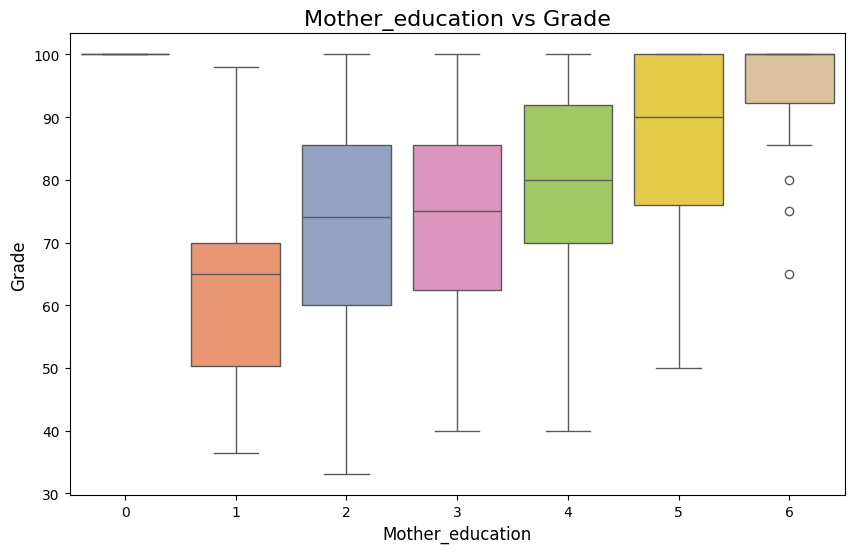

In [76]:
plot_grades_vs_column(df, 'mother_education')

<a id='model'></a>
# Applying ML Models
---

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define features (X) and target (y)
X = df.drop(columns=['grade'])  # Drop the target column
y = df['grade']  # Target column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Get feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display feature importance
print("\nFeature Importance:")
print(feature_importances)


Feature Importance:
            Feature  Importance
6    parent_revenue    0.255790
1       school_code    0.168092
7  father_education    0.134620
8  mother_education    0.115912
3     playing_often    0.104624
2     playing_years    0.087562
4     playing_hours    0.082796
0               sex    0.042826
5     playing_games    0.007778


In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Define features (X) and target (y)
X = df.drop(columns=['grade'])  # Drop the target column
y = df['grade']  # Target column

# Scale the target column 'grade'
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))  # Reshape for scaling

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train.ravel())  # Flatten y_train for compatibility

# Get feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display feature importance
print("\nFeature Importance:")
print(feature_importances)

# Optionally, reverse the scaling for predictions to interpret them on the original scale
y_pred_scaled = model.predict(X_test)
y_pred_original = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))  # Reshape for inverse scaling



Feature Importance:
            Feature  Importance
6    parent_revenue    0.256030
1       school_code    0.167264
7  father_education    0.133531
8  mother_education    0.116336
3     playing_often    0.105055
2     playing_years    0.086691
4     playing_hours    0.082631
0               sex    0.043568
5     playing_games    0.008896


In [78]:

# Make predictions on the test set
y_pred = model.predict(X_test)

In [79]:
# calculate metrics
mse = mean_squared_error(y_test, y_pred)

In [80]:
# calculate r2 score
r2 = r2_score(y_test, y_pred)

In [81]:
# calculate mean absolute error
mae = mean_absolute_error(y_test, y_pred)

In [82]:
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 0.03854935455116812
R2 Score: 0.43860136999760446
Mean Absolute Error: 0.1585508789924835


### **Interpreting the Feature Importance Results**

The feature importance values indicate how much each feature contributes to predicting the target variable (`grade`). Higher importance values mean the feature has a stronger influence on the model's predictions.

---

### **1. Most Important Features**
- **`parent_revenue` (25.60%)**:
  - This is the most important feature, suggesting that **parental income** has the strongest influence on grades. Students from families with higher income may have better access to resources that improve academic performance.

- **`school_code` (16.72%)**:
  - The second most important feature, indicating that the **school a student attends** plays a significant role in determining grades. This could reflect differences in school quality, resources, or teaching methods.

- **`father_education` (13.35%)** and **`mother_education` (11.63%)**:
  - Parental education levels are also highly influential. This suggests that students with better-educated parents tend to perform better academically, possibly due to a more supportive learning environment at home.

---

### **2. Moderately Important Features**
- **`playing_often` (10.51%)**:
  - The frequency of gaming has a moderate impact on grades. This suggests that students who game more often may see a slight negative effect on their academic performance.

- **`playing_years` (8.67%)**:
  - The number of years a student has been gaming also has a moderate influence. This could indicate that long-term gaming habits may affect grades, though the impact is less significant than other factors.

- **`playing_hours` (8.26%)**:
  - The number of hours spent gaming has a similar level of influence as `playing_years`. This suggests that the time spent gaming may slightly detract from academic performance.

---

### **3. Least Important Features**
- **`sex` (4.36%)**:
  - Gender has a relatively small impact on grades. This suggests that academic performance is not strongly influenced by whether the student is male or female.

- **`playing_games` (0.89)**:
  - The number of games played has the least influence on grades. This indicates that the variety of games a student plays is not a significant factor in academic performance.

---

### **Key Insights**
1. **Socioeconomic and Educational Factors Dominate**:
   - Features like `parent_revenue`, `school_code`, and parental education levels are the most important predictors of grades. This highlights the strong influence of socioeconomic and educational background on academic performance.

2. **Gaming Habits Have a Moderate Impact**:
   - While gaming-related features (`playing_often`, `playing_years`, `playing_hours`) do influence grades, their impact is smaller compared to socioeconomic factors. This suggests that gaming habits may affect academic performance, but they are not the primary drivers.

3. **Gender and Number of Games Are Less Relevant**:
   - Features like `sex` and `playing_games` have minimal influence, indicating that these factors are not strongly related to grades.

---

### **Model Evaluation**

1. **Mean Squared Error (MSE: 0.0385)**: This very low value suggests that the model's predictions are closely aligned with the actual grades when scaled. Since the grade column was normalized (scaled to the range 0-1), this small error indicates strong predictive accuracy within the scaled space.

2. **R² Score (0.4386)**: This shows that 44% of the variability in grades is explained by the model. While this is a good sign, it indicates there's still room for improvement in capturing more of the underlying patterns in the data.

3. **Mean Absolute Error (MAE: 0.1586)**: On average, the predictions deviate by about 0.1586 in the normalized scale (out of 1). Translating this back to the original scale of grades (0-100), the average prediction error would be approximately 15.86 points, which may warrant refinement depending.







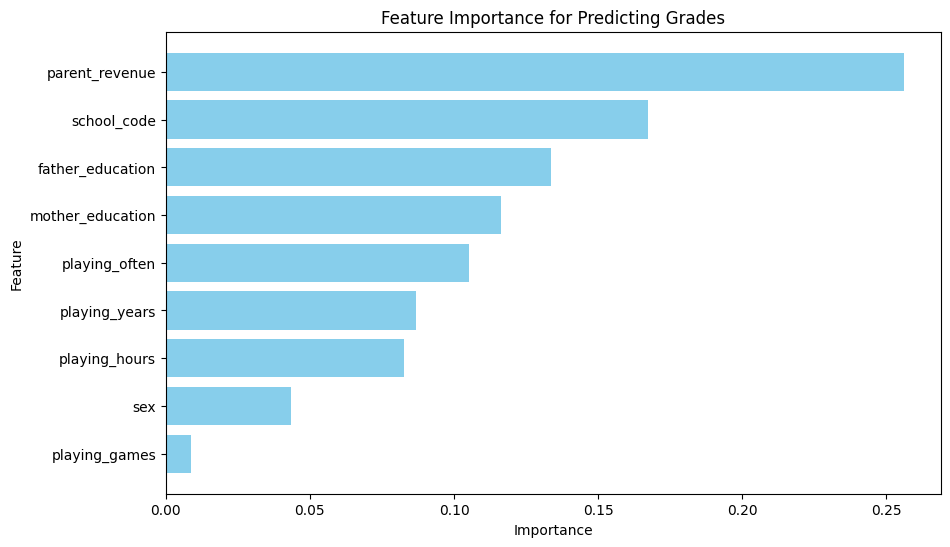

In [83]:
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Predicting Grades')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

<a id='sum'></a>
# Summary
---

### Summary of Analysis: Grades vs Gaming

This notebook explores the relationship between gaming habits and academic performance, as measured by grades. The analysis focuses on visualizing and summarizing data to identify trends and patterns.

#### Key Steps:
1. **Data Preparation**:
   - Relevant columns, such as `sex`, `grade`, and gaming-related metrics (e.g., `playing_years`), were extracted for analysis.
   - Data was cleaned and filtered to ensure accuracy.

2. **Visualization**:
   - Boxplots were created to compare grades against categorical variables like `sex` and `playing_years`.
   - These visualizations highlight potential differences in academic performance based on gaming habits or demographic factors.

3. **Pivot Table Analysis**:
   - A pivot table was generated to summarize grades (`mean`, `min`, `max`, and `count`) based on a specified index column (e.g., `school_code` or `playing_years`).
   - This provided a concise overview of grade distributions across different groups.

#### Insights:
- The visualizations and pivot tables reveal how gaming habits (e.g., years of gaming experience) and demographic factors (e.g., sex) correlate with academic performance.
- Patterns or outliers in the data may suggest areas for further investigation, such as whether excessive gaming impacts grades or if certain groups perform better academically.

#### Conclusion:
The analysis provides a foundation for understanding the interplay between gaming and grades. Further statistical testing or additional data collection is needed to draw definitive conclusions. I plan on versioning my future findings.
